# Explaining AV Decisions — Starter Notebook
This notebook loads config, initializes logging, creates the highway-env environment, and runs a short random rollout to verify setup.

In [12]:
import sys, os
# Add project root to PYTHONPATH for src imports when opened from repo root
PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)


Project root: /Users/tony/Documents/CSC790_001_XAI_Papers/Explaining-Autonomous-Vehicle-Decisions


In [13]:
# import sys
# !{sys.executable} -m pip install omegaconf gymnasium highway-env torch torchvision matplotlib pandas opencv-python seaborn shap lime tqdm pydantic rich

In [14]:
#! python3 -m pip install omegaconf
from src.utils.config import load_config
from src.utils.logging import get_logger
from src.envs.highway_env import make_env
import numpy as np
import matplotlib.pyplot as plt

In [15]:
cfg = load_config('configs/config.yaml')
logger = get_logger('notebook')
logger.info(f'Environment: {cfg.environment.name}, render={cfg.environment.render}')

2025-11-17 23:01:44,332 | INFO | notebook | Environment: highway-v0, render=False


In [16]:
import os
# Avoid Pygame trying to open a window in notebook context
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
print("SDL drivers set for headless rendering")

SDL drivers set for headless rendering


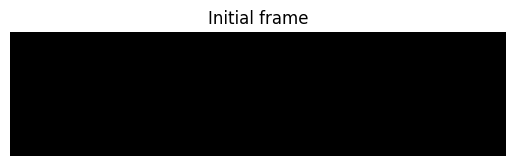

In [17]:
env = make_env(cfg)
obs, info = env.reset()
frame = env.render()  # rgb frame if render_mode=rgb_array
plt.imshow(frame)
plt.title('Initial frame')
plt.axis('off')
plt.show()

2025-11-17 23:02:20,535 | INFO | notebook | Rollout steps: 40, total reward: 29.11


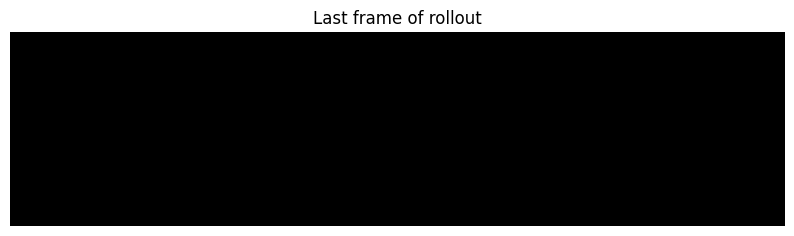

In [18]:
frames = []
rewards = []
terminated = False
truncated = False
obs, info = env.reset()
for t in range(50):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    frame = env.render()
    frames.append(frame)
    if terminated or truncated:
        break
logger.info(f'Rollout steps: {len(frames)}, total reward: {sum(rewards):.2f}')
plt.figure(figsize=(10,3))
plt.imshow(frames[-1])
plt.title('Last frame of rollout')
plt.axis('off')
plt.show()

In [19]:
env.close()
logger.info('Environment closed.')

2025-11-17 23:02:20,666 | INFO | notebook | Environment closed.


In [20]:
# Extra cleanup to avoid kernel crashes due to Pygame resources
try:
    import pygame
    pygame.display.quit()
    pygame.quit()
except Exception as e:
    print("Pygame cleanup skipped:", e)

try:
    env.close()
except Exception:
    pass

import gc
plt.close('all')
gc.collect()
print("Cleanup done.")

Cleanup done.
